# 07 - SHAP Interpretation

This notebook explains the tuned LightGBM model using SHAP values.

The goal is interpretability only. No new preprocessing, train/test split, threshold tuning, or hyperparameter search is performed here.

## 1. Why SHAP?

LightGBM feature importance shows which features are used by the model, but it does not show how individual feature values push a prediction toward higher or lower risk.

SHAP values provide local explanations for each prediction and global summaries across the test set. This is useful for checking whether the tuned model relies on clinically plausible signals.

The model explained here is the tuned LightGBM from the previous notebook. The classification threshold remains a separate decision; SHAP explains the model's prediction scores.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lightgbm import LGBMClassifier

warnings.filterwarnings(
    "ignore",
    message="LightGBM binary classifier with TreeExplainer shap values output has changed.*",
)

c:\Users\ASUS\miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DATA_DIR

WindowsPath('d:/代码集/Python/heart-disease-lightgbm/data/processed')

## 2. Load Processed Data

The same processed files are used so the explanations match the model comparison results.

In [3]:
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").squeeze("columns")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (736, 32)
X_test shape: (184, 32)
y_train shape: (736,)
y_test shape: (184,)


In [4]:
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert y_train.isna().sum() == 0
assert y_test.isna().sum() == 0
assert X_train.columns.equals(X_test.columns)
assert X_train.select_dtypes(exclude="number").empty
assert X_test.select_dtypes(exclude="number").empty

## 3. Refit the Tuned LightGBM Model

The parameters below match the best parameters found in the hyperparameter tuning notebook. The model is refit on the full training set for interpretation.

In [5]:
tuned_lightgbm_params = {
    "objective": "binary",
    "random_state": 42,
    "verbosity": -1,
    "n_jobs": -1,
    "subsample_freq": 1,
    "n_estimators": 100,
    "learning_rate": 0.08,
    "num_leaves": 7,
    "max_depth": 3,
    "min_child_samples": 50,
    "subsample": 1.0,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 0.0,
}

model = LGBMClassifier(**tuned_lightgbm_params)
model.fit(X_train, y_train)

test_proba = model.predict_proba(X_test)[:, 1]
pd.Series(test_proba).describe()

count    184.000000
mean       0.566019
std        0.351840
min        0.017577
25%        0.192677
50%        0.663173
75%        0.913325
max        0.985196
dtype: float64

## 4. Compute SHAP Values

TreeExplainer is designed for tree-based models such as LightGBM. For this binary model, positive SHAP values push a prediction toward higher predicted heart disease risk, while negative values push it toward lower predicted risk.

In [6]:
explainer = shap.TreeExplainer(model)
raw_shap_values = explainer.shap_values(X_test)

if isinstance(raw_shap_values, list):
    shap_values = raw_shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    shap_values = raw_shap_values
    expected_value = explainer.expected_value

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value: {expected_value:.3f}")

SHAP values shape: (184, 32)
Expected value: 0.310


## 5. Global SHAP Importance

Mean absolute SHAP value summarizes how strongly each feature affects predictions across the test set, regardless of direction.

In [7]:
shap_importance_df = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "MeanAbsSHAP": np.abs(shap_values).mean(axis=0),
    }
).sort_values("MeanAbsSHAP", ascending=False)

shap_importance_df.head(15)

,Feature,MeanAbsSHAP
11,cat__cp_asymptomatic,0.573116
4,num__oldpeak,0.460262
20,cat__exang_False,0.308866
9,cat__dataset_Switzerland,0.297940
2,num__chol,0.270157
25,cat__ca_0.0,0.268239
5,cat__sex_Female,0.265528
0,num__age,0.258363
12,cat__cp_atypical angina,0.246305
7,cat__dataset_Cleveland,0.206300


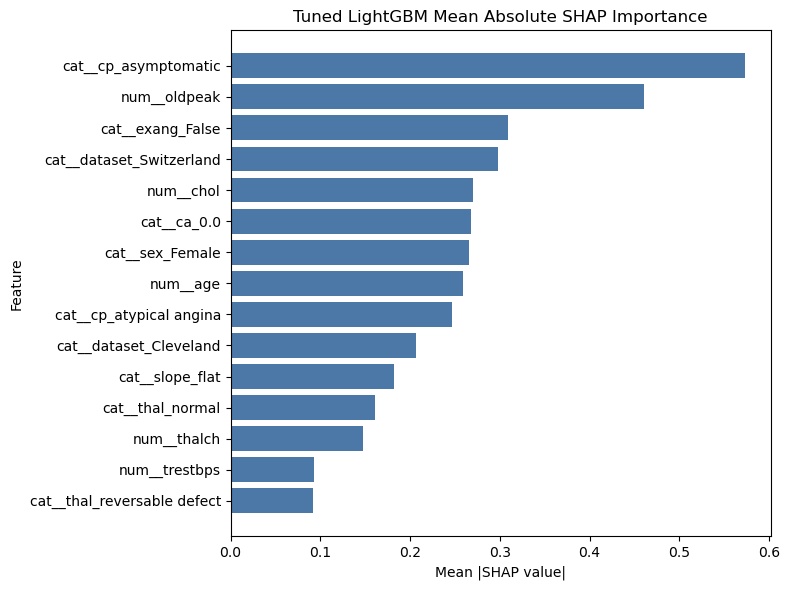

In [8]:
top_shap_features = shap_importance_df.head(15).sort_values("MeanAbsSHAP")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_shap_features["Feature"], top_shap_features["MeanAbsSHAP"], color="#4C78A8")
ax.set_title("Tuned LightGBM Mean Absolute SHAP Importance")
ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("Feature")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "shap_feature_importance_bar.png", dpi=150, bbox_inches="tight")

## 6. SHAP Summary Plot

The beeswarm plot shows both importance and direction. Points to the right push predictions toward higher risk; points to the left push predictions toward lower risk.

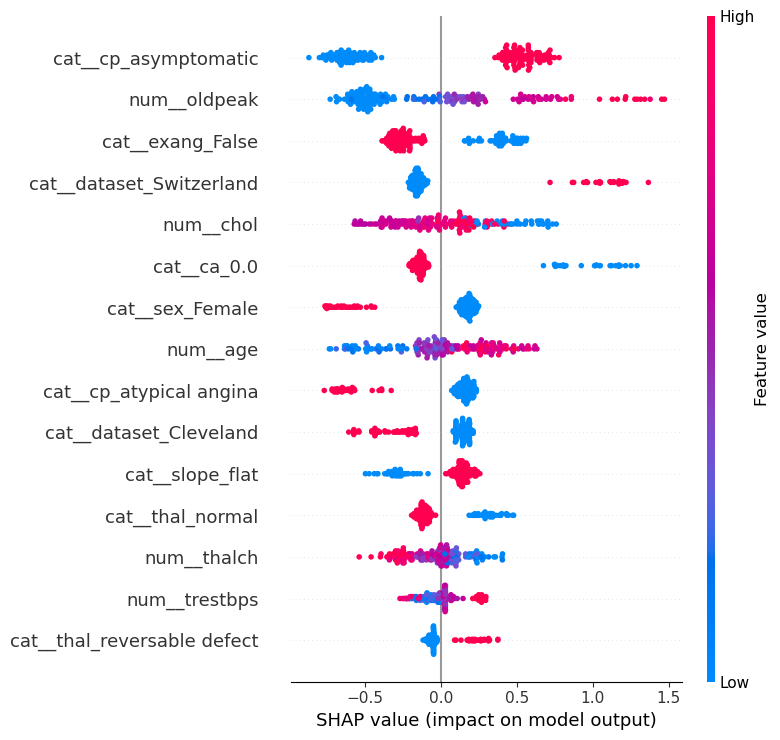

In [9]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

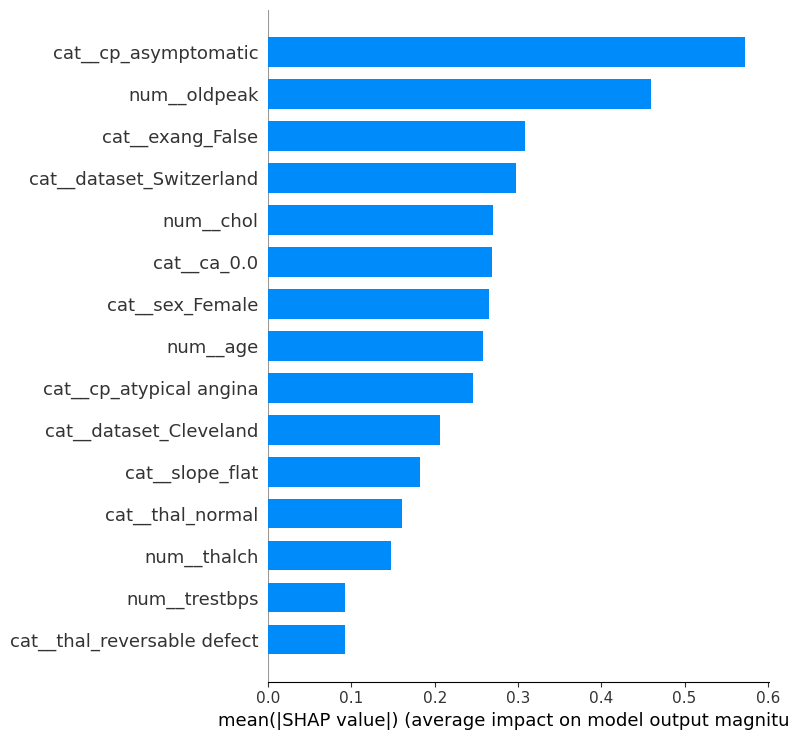

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Local Explanation for a High-Risk Prediction

The waterfall plot explains one test-set patient with a high predicted probability. It shows which features moved the prediction away from the baseline expected value.

In [11]:
high_risk_position = int(np.argmax(test_proba))
high_risk_probability = test_proba[high_risk_position]

print(f"Selected test row position: {high_risk_position}")
print(f"Predicted probability: {high_risk_probability:.3f}")

Selected test row position: 172
Predicted probability: 0.985


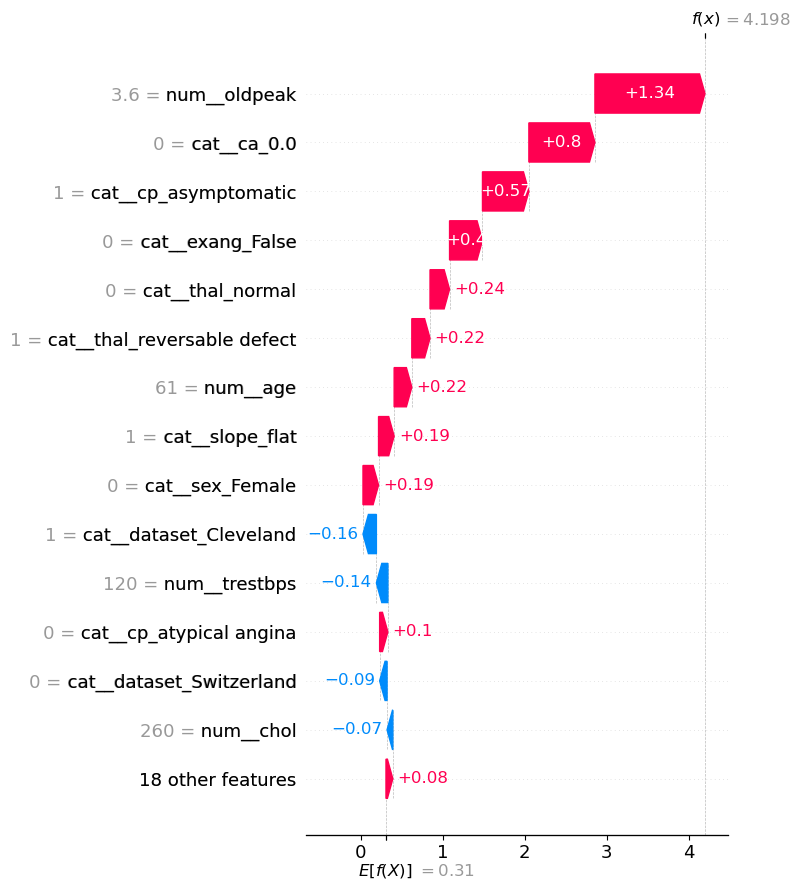

In [12]:
high_risk_explanation = shap.Explanation(
    values=shap_values[high_risk_position],
    base_values=expected_value,
    data=X_test.iloc[high_risk_position],
    feature_names=X_test.columns,
)

plt.figure()
shap.plots.waterfall(high_risk_explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_high_risk_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save SHAP Summary Report

The report records the top SHAP features and a short interpretation for project documentation.

In [13]:
top_10_shap = shap_importance_df.head(10).copy()
top_10_shap["MeanAbsSHAP"] = top_10_shap["MeanAbsSHAP"].round(3)

report_lines = [
    "# SHAP Interpretation Summary",
    "",
    "This report explains the tuned LightGBM model using SHAP values on the held-out test set.",
    "",
    "Positive SHAP values push predictions toward higher heart disease risk, while negative SHAP values push predictions toward lower risk.",
    "",
    "## Top SHAP Features",
    "",
    "| Feature | MeanAbsSHAP |",
    "| --- | ---: |",
]

for _, row in top_10_shap.iterrows():
    report_lines.append(f"| {row['Feature']} | {row['MeanAbsSHAP']:.3f} |")

report_lines.extend(
    [
        "",
        "## Interpretation Notes",
        "",
        "The strongest SHAP signals include chest pain category, ST depression (`oldpeak`), exercise-induced angina, cholesterol, ca, sex, age, and dataset indicators.",
        "",
        "These features are clinically plausible for a heart disease risk model, but SHAP values explain model behavior rather than proving causal effects.",
        "",
    ]
)

(REPORTS_DIR / "shap_summary.md").write_text("\n".join(report_lines), encoding="utf-8")
top_10_shap

,Feature,MeanAbsSHAP
11,cat__cp_asymptomatic,0.573
4,num__oldpeak,0.460
20,cat__exang_False,0.309
9,cat__dataset_Switzerland,0.298
2,num__chol,0.270
25,cat__ca_0.0,0.268
5,cat__sex_Female,0.266
0,num__age,0.258
12,cat__cp_atypical angina,0.246
7,cat__dataset_Cleveland,0.206


## 9. Summary

The tuned LightGBM model relies heavily on chest pain indicators, `oldpeak`, exercise-induced angina, cholesterol, ca, sex, age, and dataset indicators.

These findings are broadly plausible, but they should be interpreted as model explanations, not clinical causal claims. The one-hot encoded features also mean some SHAP values represent category indicators rather than original raw columns.